# 01 Curve Build

This notebook builds a Treasury zero curve from the raw par-yield input and prepares the benchmark discount curve used throughout the valuation workflow.

The starting point is a daily Treasury par-yield table. The purpose of this step is to convert those quoted market yields into discount factors and zero rates that can be applied consistently across every bond in the universe.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from src.curve import build_zero_curve, format_curve_table, load_treasury_curve

In [3]:
curve_path = PROJECT_ROOT / "data" / "raw" / "treasury_curve.csv"
history = load_treasury_curve(curve_path)
history.tail()

,date,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,30Y
60,2026-03-31,3.70,3.72,3.68,3.79,3.81,3.92,4.11,4.30,4.88
61,2026-04-01,3.70,3.72,3.68,3.81,3.84,3.97,4.15,4.33,4.91
62,2026-04-02,3.70,3.72,3.68,3.79,3.82,3.94,4.12,4.31,4.88
63,2026-04-03,3.71,3.73,3.72,3.84,3.88,3.99,4.17,4.35,4.91
64,2026-04-06,3.72,3.74,3.72,3.84,3.88,3.98,4.16,4.34,4.89


In [4]:
eval_date = history.iloc[-1]["date"].strftime("%Y-%m-%d")
as_of_date, zero_curve = build_zero_curve(curve_path, eval_date=eval_date)
display_curve = format_curve_table(zero_curve)
display_curve

,date,maturity_years,par_yield,discount_factor,zero_rate
0,2026-04-06,0.25,3.72,0.990786,3.7722
1,2026-04-06,0.50,3.74,0.981643,3.7750
2,2026-04-06,1.00,3.72,0.963814,3.7544
3,2026-04-06,2.00,3.84,0.926687,3.8803
4,2026-04-06,3.00,3.88,0.891021,3.9212
5,2026-04-06,5.00,3.98,0.820698,4.0311
6,2026-04-06,7.00,4.16,0.747939,4.2363
7,2026-04-06,10.00,4.34,0.647054,4.4494
8,2026-04-06,30.00,4.89,0.187288,5.7425


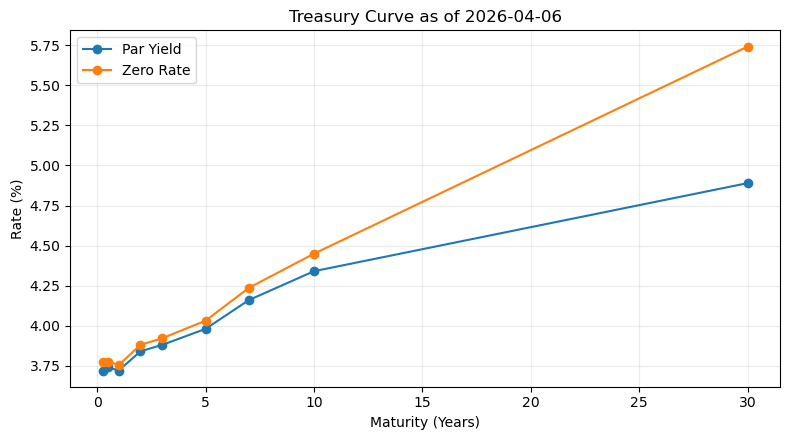

In [5]:
plt.figure(figsize=(8, 4.5))
plt.plot(display_curve["maturity_years"], display_curve["par_yield"], marker="o", label="Par Yield")
plt.plot(display_curve["maturity_years"], display_curve["zero_rate"], marker="o", label="Zero Rate")
plt.xlabel("Maturity (Years)")
plt.ylabel("Rate (%)")
plt.title(f"Treasury Curve as of {as_of_date.date()}")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

A full curve build would need more instruments and convention handling. For this project, the simpler bootstrap is enough to create a benchmark curve for the later pricing steps.